<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #16a34a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Fundamentos de Árboles y Algoritmo CART 🌳📜
      </h1>
      <p style="margin: 6px 0 0 0; color: #16a34a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Classification and Regression Trees
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #15803d; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 04 • Data Mining
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #16a34a; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Mining/04%20-%20Arboles%20de%20Decision%20y%20Bosques%20Aleatorios/00_Fundamentos_de_Arboles_y_Algoritmo_CART.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. ¿Qué es un árbol de decisión? De las "20 preguntas" a una definición formal 🌳

El juego de las **"20 preguntas"** — adivinar un objeto haciendo preguntas de sí/no cada vez más específicas — es la intuición más común detrás de un árbol de decisión, y no es una mala intuición. Formalmente, un **árbol de decisión** es un modelo predictivo que aprende una jerarquía de **reglas binarias simples** sobre las variables predictoras, y usa esa jerarquía para asignar una predicción a cada observación.

De forma más rigurosa: dado un espacio de características $\mathcal{X} \subseteq \mathbb{R}^p$, un árbol de decisión particiona $\mathcal{X}$ en un conjunto de **regiones disjuntas** $R_1, R_2, \dots, R_M$ (los hiper-rectángulos que corresponden a las hojas del árbol) mediante una secuencia de **cortes ortogonales a los ejes** (*axis-aligned splits*) de la forma:

$$x_j \le t \quad \text{vs.} \quad x_j > t$$

donde $x_j$ es una única variable predictora y $t$ es un umbral (*threshold*) numérico. Cada observación recorre el árbol desde la raíz respondiendo estas preguntas binarias una tras otra, hasta caer en una región $R_m$, donde recibe como predicción un valor constante:

* En **clasificación**, la clase mayoritaria de las observaciones de entrenamiento que cayeron en $R_m$.
* En **regresión**, el promedio de $y$ entre esas mismas observaciones.

La restricción de que cada corte use **una sola variable a la vez** (nunca combinaciones lineales como $2x_1 + 3x_2 \le t$) es justamente lo que hace que las fronteras de decisión de un árbol sean rectangulares y no diagonales — una limitación real que se retoma en la Sección 8.

### 1.1 Anatomía de un árbol: raíz, nodos internos y hojas 🧩

Todo árbol de decisión comparte la misma terminología, heredada de la teoría de grafos:

| Elemento | Definición | Rol |
|---|---|---|
| **Nodo raíz** (*root node*) | El nodo superior, que contiene el 100% de las observaciones de entrenamiento. | Punto de partida de toda predicción. |
| **Nodo interno / de decisión** (*decision node*) | Cualquier nodo que aplica una regla $x_j \le t$ y reparte sus observaciones entre dos nodos hijos. | Aplica una pregunta y decide hacia dónde continuar. |
| **Nodo hoja / terminal** (*leaf node*) | Un nodo sin hijos: no se divide más. | Emite la predicción final (clase mayoritaria o promedio). |
| **Profundidad** (*depth*) | Número de divisiones desde la raíz hasta un nodo dado. La raíz tiene profundidad 0. | Controla qué tan compleja puede ser una regla (cuántas condiciones "Y" encadena). |

Un diagrama esquemático de un árbol de profundidad 2 (`max_depth=2`) para `churn`:

```
                    [ RAÍZ: tipo_contrato_ord <= 0.5 ? ]
                     /                              \
                   Sí                                No
                   /                                    \
      [antiguedad_meses <= 24.5?]              [antiguedad_meses <= 24.5?]
        /              \                          /               \
      Sí               No                        Sí               No
      /                  \                       /                  \
  [HOJA]              [HOJA]                  [HOJA]              [HOJA]
  clase: ?            clase: ?                clase: ?            clase: ?
```

Nótese que **cada nodo interno solo usa una variable**, pero el mismo predictor puede reaparecer en ramas distintas con umbrales distintos (como ocurre aquí con `antiguedad_meses` en ambas ramas) — el árbol no "gasta" una variable al usarla una vez.

---
## 2. El algoritmo CART (Breiman et al., 1984) 🔍

**CART** (*Classification And Regression Trees*) es el algoritmo que `scikit-learn` implementa para construir árboles de decisión. Es un procedimiento **voraz** (*greedy*), **recursivo** y de **partición binaria descendente** (*top-down recursive binary splitting*). "Voraz" es la palabra clave: en cada paso CART elige la mejor división **posible en ese momento**, sin mirar hacia adelante para ver si una división aparentemente peor ahora permitiría mejores divisiones más adelante — no garantiza el árbol globalmente óptimo, solo una buena aproximación construida paso a paso.

El procedimiento, en pseudocódigo:

```
función CONSTRUIR_ARBOL(nodo, datos):
    si se cumple un criterio de parada (profundidad máxima, muy pocas observaciones, nodo puro):
        convertir "nodo" en HOJA y asignar la predicción (clase mayoritaria / promedio)
        retornar

    mejor_division = None
    mejor_ganancia = -infinito

    para cada variable x_j en los datos:
        para cada umbral candidato t (típicamente los puntos medios entre valores consecutivos observados de x_j):
            dividir "datos" en (izquierda: x_j <= t) y (derecha: x_j > t)
            calcular la ganancia de pureza de esta división
            si ganancia > mejor_ganancia:
                mejor_division = (x_j, t)
                mejor_ganancia = ganancia

    aplicar mejor_division, creando nodo_izquierdo y nodo_derecho
    CONSTRUIR_ARBOL(nodo_izquierdo, datos_izquierda)   # recursión
    CONSTRUIR_ARBOL(nodo_derecho, datos_derecha)        # recursión
```

Dos ideas merecen subrayarse:

1. **"Todas las variables y todos los umbrales":** en cada nodo, CART no elige entre un puñado de opciones — evalúa exhaustivamente cada variable disponible y, para cada una, cada umbral candidato razonable. Es un procedimiento costoso mitigado por implementaciones eficientes (ordenar valores una vez, evaluar cortes en $O(n \log n)$), pero conceptualmente es una búsqueda exhaustiva local.
2. **"Ganancia de pureza":** ¿cómo se mide qué tan buena es una división? Ese es exactamente el tema del **Cuaderno 01** de este módulo (`01_Criterios_de_Division_Gini_Entropia_y_MSE.ipynb`), donde se formalizan las fórmulas de **Gini**, **Entropía** e **MSE**. Aquí basta con la idea intuitiva: una buena división separa las observaciones en grupos donde predomina claramente una sola clase (o, en regresión, donde los valores de $y$ son similares entre sí).

---
## 3. Los datos: `abandono_clientes_telecom.csv` 📡

El resto de este cuaderno trabaja sobre un problema real de **abandono de clientes** (*churn*) de una empresa de telecomunicaciones: predecir si un cliente cancelará su servicio (`churn = 1`) a partir de variables de facturación, antigüedad y tipo de contrato. Antes de entrenar cualquier modelo, se exploran los datos para conocer su forma exacta.

In [1]:
try:
    display
except NameError:
    display = print

import os, urllib.request, urllib.parse, gzip, base64

_DATA_EMBEDDED = {
    "abandono_clientes_telecom.csv": "...",
}

def load_dataset(filename: str) -> str:
    candidates = [
        os.path.join("data", filename),
        os.path.join("..", "data", filename),
        os.path.join("04 - Arboles de Decision y Bosques Aleatorios", "data", filename),
        os.path.join("Data Mining", "04 - Arboles de Decision y Bosques Aleatorios", "data", filename),
        os.path.join("..", "04 - Arboles de Decision y Bosques Aleatorios", "data", filename),
        filename,
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    os.makedirs("data", exist_ok=True)
    target = os.path.join("data", filename)
    base_url = "https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Mining/04%20-%20Arboles%20de%20Decision%20y%20Bosques%20Aleatorios/data/"
    url = base_url + urllib.parse.quote(filename)
    try:
        urllib.request.urlretrieve(url, target, timeout=3)
        return target
    except Exception:
        pass
    if filename in _DATA_EMBEDDED:
        raw = gzip.decompress(base64.b64decode(_DATA_EMBEDDED[filename]))
        with open(target, "wb") as f:
            f.write(raw)
        return target
    raise FileNotFoundError(f"No se pudo obtener el dataset: {filename}")

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, os
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

df_telecom = pd.read_csv(load_dataset("abandono_clientes_telecom.csv"))
print(f"abandono_clientes_telecom.csv -> {df_telecom.shape[0]} filas x {df_telecom.shape[1]} columnas")
display(df_telecom.head(3))
df_telecom.info()

print("\nDistribucion de la variable objetivo (churn):")
print(df_telecom["churn"].value_counts())
print(df_telecom["churn"].value_counts(normalize=True).round(4))

print("\ntipo_contrato:")
print(df_telecom["tipo_contrato"].value_counts())
print("\nsoporte_tecnico:")
print(df_telecom["soporte_tecnico"].value_counts())
print("\nfactura_electronica:")
print(df_telecom["factura_electronica"].value_counts())

abandono_clientes_telecom.csv -> 2500 filas x 7 columnas


,antiguedad_meses,cargo_mensual,cargos_totales,soporte_tecnico,tipo_contrato,factura_electronica,churn
0,35,113.200,"4,200.880",Si,Un_Ano,No,0
1,40,117.140,"4,500.350",Sin_Internet,Un_Ano,Si,0
2,59,108.060,"6,183.800",Sin_Internet,Un_Ano,No,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   antiguedad_meses     2500 non-null   int64  
 1   cargo_mensual        2500 non-null   float64
 2   cargos_totales       2500 non-null   float64
 3   soporte_tecnico      2500 non-null   object 
 4   tipo_contrato        2500 non-null   object 
 5   factura_electronica  2500 non-null   object 
 6   churn                2500 non-null   int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 136.8+ KB

Distribucion de la variable objetivo (churn):
churn
0    1778
1     722
Name: count, dtype: int64
churn
0   0.711
1   0.289
Name: proportion, dtype: float64

tipo_contrato:
tipo_contrato
Mes_a_Mes    1379
Un_Ano        628
Dos_Anos      493
Name: count, dtype: int64

soporte_tecnico:
soporte_tecnico
No              1116
Si               873
Sin_Internet     511
Name: count, dt

**Lectura de la exploración:** el dataset tiene 2500 clientes sin valores nulos. `churn` está desbalanceado (71.12% no abandona, 28.88% sí abandona) pero no de forma extrema. Tres columnas son categóricas de tipo texto: `tipo_contrato` (con un orden natural de compromiso: `Mes_a_Mes` < `Un_Ano` < `Dos_Anos`), `factura_electronica` (binaria `Si`/`No`), y `soporte_tecnico`. Esta última merece una aclaración honesta: aunque a primera vista parece binaria, en realidad tiene **tres** categorías (`No`: 1116, `Si`: 873, `Sin_Internet`: 511) — un tercer grupo de clientes que no tiene servicio de internet y para quienes la pregunta "¿tiene soporte técnico?" no aplica. Esto se refleja en la codificación de la siguiente sección.

---
## 4. Preparación de los datos: codificando variables categóricas ⚙️

`DecisionTreeClassifier` de `scikit-learn` —a diferencia de algunas implementaciones de árboles en otros lenguajes— **no acepta texto directamente como entrada**: aunque conceptualmente un árbol puede manejar variables categóricas sin problema (una división del tipo "¿el contrato es Mes_a_Mes?" es tan válida como "¿antiguedad_meses ≤ 24?"), la implementación de `scikit-learn` exige que todas las columnas sean numéricas. Es una limitación **de la librería**, no del algoritmo CART en abstracto — conviene ser explícitos sobre esa distinción.

La codificación usada en este módulo, consistente entre este cuaderno y el siguiente:

* **`factura_electronica`** (`Si`/`No`): mapeo binario trivial a `{0, 1}`.
* **`tipo_contrato`**: tiene un **orden natural de compromiso** (`Mes_a_Mes` < `Un_Ano` < `Dos_Anos`), así que se usa `OrdinalEncoder` con `categories` explícitas para preservar ese orden como `{0, 1, 2}` — una codificación *One-Hot* perdería esa información ordinal sin necesidad.
* **`soporte_tecnico`** (3 categorías sin orden natural: `No`, `Si`, `Sin_Internet`): al no existir una relación de orden razonable entre "no tiene soporte", "sí tiene soporte" y "no tiene internet", se usa **One-Hot Encoding** (`pd.get_dummies`), generando las columnas `soporte_No`, `soporte_Si`, `soporte_Sin_Internet`.

In [2]:
try:
    display
except NameError:
    display = print

df_prep = df_telecom.copy()

# factura_electronica: mapeo binario
df_prep["factura_electronica"] = df_prep["factura_electronica"].map({"No": 0, "Si": 1})

# tipo_contrato: OrdinalEncoder respetando el orden de compromiso Mes_a_Mes < Un_Ano < Dos_Anos
orden_contrato = [["Mes_a_Mes", "Un_Ano", "Dos_Anos"]]
encoder_contrato = OrdinalEncoder(categories=orden_contrato)
df_prep["tipo_contrato_ord"] = encoder_contrato.fit_transform(df_prep[["tipo_contrato"]]).astype(int)

# soporte_tecnico: One-Hot (3 categorias sin orden natural)
soporte_dummies = pd.get_dummies(df_prep["soporte_tecnico"], prefix="soporte").astype(int)
df_prep = pd.concat([df_prep, soporte_dummies], axis=1)

feature_cols = ["antiguedad_meses", "cargo_mensual", "cargos_totales",
                 "tipo_contrato_ord", "factura_electronica",
                 "soporte_No", "soporte_Si", "soporte_Sin_Internet"]

X = df_prep[feature_cols]
y = df_prep["churn"]

display(X.head(3))
print(f"\nFeatures listas para el modelo: {feature_cols}")

,antiguedad_meses,cargo_mensual,cargos_totales,tipo_contrato_ord,factura_electronica,soporte_No,soporte_Si,soporte_Sin_Internet
0,35,113.200,"4,200.880",1,0,0,1,0
1,40,117.140,"4,500.350",1,1,0,0,1
2,59,108.060,"6,183.800",1,0,0,0,1



Features listas para el modelo: ['antiguedad_meses', 'cargo_mensual', 'cargos_totales', 'tipo_contrato_ord', 'factura_electronica', 'soporte_No', 'soporte_Si', 'soporte_Sin_Internet']


---
## 5. Primer árbol real: `DecisionTreeClassifier` sobre `churn` 🎯

Se entrena un árbol restringido a `max_depth=3`. La restricción es deliberada: un árbol sin límite de profundidad puede alcanzar decenas de niveles (se demuestra en la Sección 8), volviéndose imposible de leer o explicar — y esa es precisamente la ventaja que se busca demostrar aquí. Con solo 3 niveles, el árbol completo cabe en una sola visualización y cada regla se puede leer en voz alta.

In [3]:
arbol = DecisionTreeClassifier(max_depth=3, random_state=42)
arbol.fit(X, y)

print(f"Exactitud del arbol (max_depth=3) sobre los datos de entrenamiento: {arbol.score(X, y)*100:.2f}%")
print(f"Numero de nodos: {arbol.tree_.node_count}  |  Numero de hojas: {arbol.get_n_leaves()}  |  Profundidad: {arbol.get_depth()}")

Exactitud del arbol (max_depth=3) sobre los datos de entrenamiento: 75.00%
Numero de nodos: 15  |  Numero de hojas: 8  |  Profundidad: 3


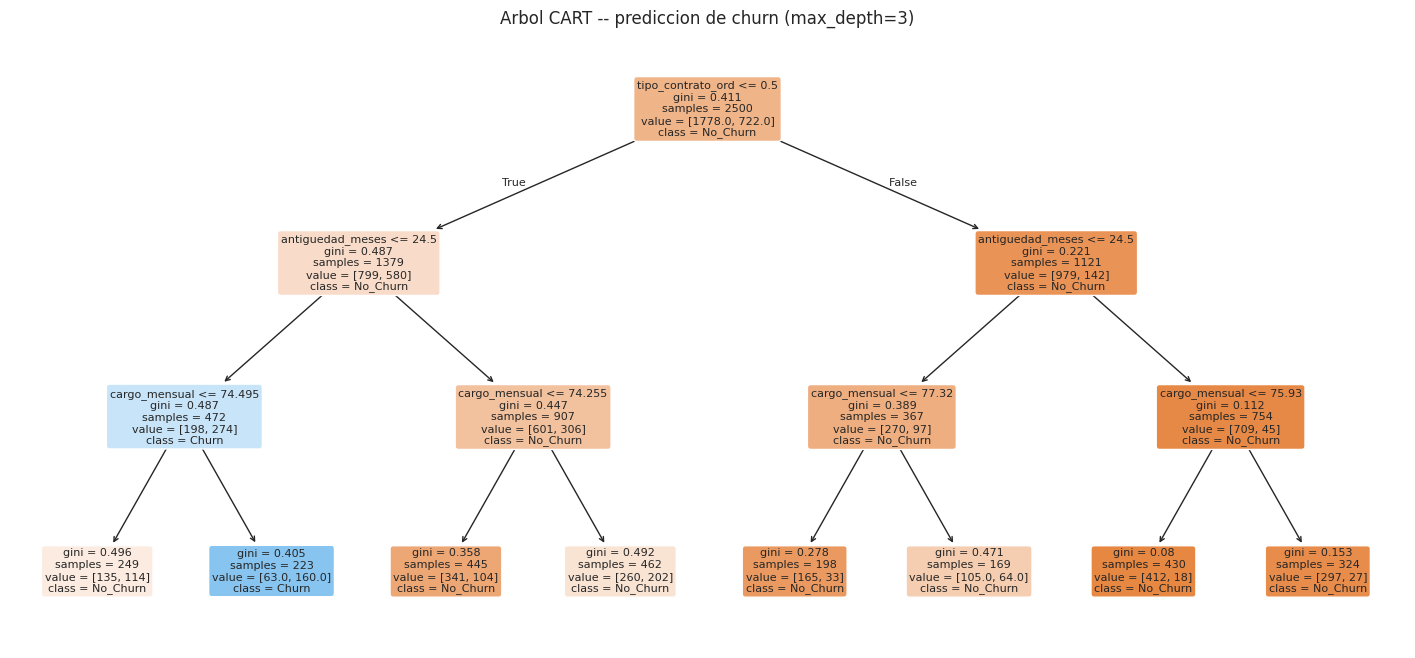

In [4]:
plt.figure(figsize=(18, 8))
plot_tree(arbol, feature_names=feature_cols, class_names=["No_Churn", "Churn"],
          filled=True, rounded=True, fontsize=8)
plt.title("Arbol CART -- prediccion de churn (max_depth=3)")
plt.show()

`plot_tree` es útil para una vista panorámica, pero para leer las reglas con precisión (los umbrales exactos, sin depender del tamaño de la fuente) `export_text` es más práctico:

In [5]:
print(export_text(arbol, feature_names=feature_cols))

|--- tipo_contrato_ord <= 0.50
|   |--- antiguedad_meses <= 24.50
|   |   |--- cargo_mensual <= 74.49
|   |   |   |--- class: 0
|   |   |--- cargo_mensual >  74.49
|   |   |   |--- class: 1
|   |--- antiguedad_meses >  24.50
|   |   |--- cargo_mensual <= 74.26
|   |   |   |--- class: 0
|   |   |--- cargo_mensual >  74.26
|   |   |   |--- class: 0
|--- tipo_contrato_ord >  0.50
|   |--- antiguedad_meses <= 24.50
|   |   |--- cargo_mensual <= 77.32
|   |   |   |--- class: 0
|   |   |--- cargo_mensual >  77.32
|   |   |   |--- class: 0
|   |--- antiguedad_meses >  24.50
|   |   |--- cargo_mensual <= 75.93
|   |   |   |--- class: 0
|   |   |--- cargo_mensual >  75.93
|   |   |   |--- class: 0



---
## 6. Interpretabilidad: leyendo reglas de decisión en lenguaje de negocio 💬

La ventaja más citada de los árboles de decisión frente a modelos "caja negra" (redes neuronales, ensambles complejos) es que **cada predicción se puede justificar con una regla explícita**, legible por una persona sin formación técnica. La siguiente celda recorre cada nodo del árbol entrenado e imprime, para cada uno, la regla que aplica (si es un nodo de división) o la predicción final (si es una hoja), junto con el número de clientes que caen ahí y la proporción real que abandonó.

In [6]:
t = arbol.tree_
print(f"{'Nodo':<5}{'Tipo':<10}{'Regla / Prediccion':<45}{'n':<7}{'p(churn=1)':<12}")
for i in range(t.node_count):
    es_hoja = t.children_left[i] == t.children_right[i]
    n = t.n_node_samples[i]
    p1 = t.value[i][0][1]
    if es_hoja:
        pred = "Churn" if p1 > 0.5 else "No_Churn"
        print(f"{i:<5}{'HOJA':<10}{'prediccion -> ' + pred:<45}{n:<7}{p1:<12.4f}")
    else:
        regla = f"{feature_cols[t.feature[i]]} <= {t.threshold[i]:.2f}"
        print(f"{i:<5}{'DIVISION':<10}{regla:<45}{n:<7}{p1:<12.4f}")

Nodo Tipo      Regla / Prediccion                           n      p(churn=1)  
0    DIVISION  tipo_contrato_ord <= 0.50                    2500   0.2888      
1    DIVISION  antiguedad_meses <= 24.50                    1379   0.4206      
2    DIVISION  cargo_mensual <= 74.49                       472    0.5805      
3    HOJA      prediccion -> No_Churn                       249    0.4578      
4    HOJA      prediccion -> Churn                          223    0.7175      
5    DIVISION  cargo_mensual <= 74.26                       907    0.3374      
6    HOJA      prediccion -> No_Churn                       445    0.2337      
7    HOJA      prediccion -> No_Churn                       462    0.4372      
8    DIVISION  antiguedad_meses <= 24.50                    1121   0.1267      
9    DIVISION  cargo_mensual <= 77.32                       367    0.2643      
10   HOJA      prediccion -> No_Churn                       198    0.1667      
11   HOJA      prediccion -> No_Churn   

**Dos caminos concretos, traducidos a lenguaje de negocio:**

* **Nodo 4 (perfil de ALTO riesgo, 223 clientes, 71.75% abandona):** *"SI `tipo_contrato` es `Mes_a_Mes` Y `antiguedad_meses` ≤ 24.5 Y `cargo_mensual` > 74.5, ENTONCES el cliente tiene 71.75% de probabilidad de abandonar."* Es el perfil clásico de riesgo en telecomunicaciones: cliente nuevo (menos de 2 años), sin compromiso contractual (mes a mes, puede irse cuando quiera) y con una factura relativamente alta — pocos incentivos para quedarse y un costo mensual que motiva a buscar alternativas.
* **Nodo 13 (perfil de BAJO riesgo, 430 clientes, solo 4.19% abandona):** *"SI `tipo_contrato` NO es `Mes_a_Mes` (`Un_Ano` o `Dos_Anos`) Y `antiguedad_meses` > 24.5 Y `cargo_mensual` ≤ 75.9, ENTONCES el cliente tiene apenas 4.19% de probabilidad de abandonar."* El perfil opuesto: cliente con antigüedad considerable, contrato con compromiso de permanencia y una factura moderada — la combinación casi ideal de lealtad.

La diferencia entre 71.75% y 4.19% de riesgo, derivada de tres condiciones legibles, es exactamente el tipo de explicación que un equipo de retención de clientes puede accionar directamente ("prioricemos llamadas a clientes con contrato mes a mes, antigüedad menor a 2 años y factura alta") — algo mucho más difícil de extraer de un modelo que solo entrega una probabilidad sin estructura interpretable.

---
## 7. Propiedades clave de los árboles de decisión ⚖️

| Propiedad | Árboles de decisión | Contraste con módulos anteriores |
|---|---|---|
| **Escalado de variables** | **No es necesario.** Un árbol solo compara $x_j$ contra un umbral $t$ de la misma variable; multiplicar $x_j$ por una constante desplaza $t$ proporcionalmente pero no cambia qué observaciones caen a cada lado. | k-NN (basado en distancias) y regresión logística (basada en gradiente) **sí** requieren `StandardScaler` — ver Módulo 02. |
| **Variables mixtas (numéricas + categóricas)** | En teoría, un árbol puede dividir directamente sobre categorías (`¿tipo_contrato == "Mes_a_Mes"?`) sin necesidad de convertirlas a números. **En la práctica, `scikit-learn` exige codificación numérica previa** (Sección 4) — una limitación de la implementación, no del algoritmo CART. | Regresión logística también exige codificación numérica, pero además exige que esa codificación sea "razonable" para el modelo lineal subyacente (por eso el One-Hot en `soporte_tecnico`). |
| **Forma funcional** | **No paramétrico:** no asume que la relación entre $X$ y $y$ sea lineal, cuadrática, ni de ninguna forma predefinida — el árbol descubre la estructura directamente de los datos mediante particiones sucesivas. | La regresión lineal/logística **sí** asume una forma funcional específica (una combinación lineal de las variables). |

La siguiente celda verifica empíricamente la primera fila de la tabla: se entrena el mismo árbol sobre los datos originales y sobre una versión estandarizada (`StandardScaler`) de las columnas numéricas, y se comparan las predicciones.

In [7]:
scaler = StandardScaler()
cols_numericas = ["antiguedad_meses", "cargo_mensual", "cargos_totales"]
X_escalado = X.copy()
X_escalado[cols_numericas] = scaler.fit_transform(X[cols_numericas])

arbol_escalado = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_escalado, y)

print(f"Exactitud con datos originales:  {arbol.score(X, y):.4f}")
print(f"Exactitud con datos escalados:   {arbol_escalado.score(X_escalado, y):.4f}")
print(f"Predicciones identicas en ambos casos: {np.array_equal(arbol.predict(X), arbol_escalado.predict(X_escalado))}")

Exactitud con datos originales:  0.7500
Exactitud con datos escalados:   0.7500
Predicciones identicas en ambos casos: True


**Resultado:** ambos árboles alcanzan exactamente la misma exactitud (75.00%) y producen predicciones idénticas para cada cliente — el escalado no cambió absolutamente nada. Esto confirma la teoría: el árbol simplemente eligió los mismos umbrales, ahora expresados en unidades estandarizadas en lugar de las unidades originales (por ejemplo, `cargo_mensual <= 74.49` en escala original se convierte en algo como `cargo_mensual <= 0.07` en escala estandarizada, pero corresponde exactamente al mismo corte).

---
## 8. La principal debilidad: alta varianza e inestabilidad 🌪️

Los árboles de decisión tienen una propiedad estadística incómoda: son modelos de **alta varianza**. Pequeños cambios en los datos de entrenamiento —incluso remuestreando las mismas observaciones con reemplazo (*bootstrap*)— pueden producir árboles con divisiones bastante distintas, especialmente en los niveles más profundos.

La siguiente celda entrena 6 árboles idénticos (`max_depth=3`, mismos hiperparámetros) sobre 6 muestras *bootstrap* distintas de los mismos 2500 clientes, y observa qué variable/umbral elige cada uno en el **nodo 1** (el hijo izquierdo de la raíz, es decir, el segundo nivel del árbol dentro de la rama `Mes_a_Mes`).

In [8]:
rng = np.random.RandomState(0)
print("Division en el nodo 1 (segundo nivel, rama Mes_a_Mes) segun la muestra bootstrap:")
for i in range(6):
    idx = rng.choice(len(X), size=len(X), replace=True)
    Xb, yb = X.iloc[idx], y.iloc[idx]
    arbol_b = DecisionTreeClassifier(max_depth=3, random_state=42).fit(Xb, yb)
    nodo1 = arbol_b.tree_.children_left[0]
    nombre = feature_cols[arbol_b.tree_.feature[nodo1]]
    umbral = arbol_b.tree_.threshold[nodo1]
    print(f"  muestra {i}: {nombre} <= {umbral:.3f}")

Division en el nodo 1 (segundo nivel, rama Mes_a_Mes) segun la muestra bootstrap:
  muestra 0: cargo_mensual <= 74.325
  muestra 1: cargo_mensual <= 75.025
  muestra 2: antiguedad_meses <= 25.500
  muestra 3: antiguedad_meses <= 24.500
  muestra 4: antiguedad_meses <= 23.500
  muestra 5: cargo_mensual <= 74.145


**Lectura:** el nodo raíz (`tipo_contrato_ord <= 0.5`) es tan dominante en poder predictivo que se mantiene estable en las 6 muestras — pero ya en el **segundo nivel** la variable elegida cambia entre `cargo_mensual` (muestras 0, 1, 5) y `antiguedad_meses` (muestras 2, 3, 4), con umbrales que varían de 23.5 a 25.5 incluso cuando coincide la variable. Con `max_depth=3` el efecto es moderado porque el árbol es muy simple. La siguiente celda quita esa restricción para mostrar el efecto en su forma más extrema.

In [9]:
print("Arboles SIN restriccion de profundidad sobre distintas muestras bootstrap:")
for i in range(5):
    idx = rng.choice(len(X), size=len(X), replace=True)
    Xb, yb = X.iloc[idx], y.iloc[idx]
    arbol_b = DecisionTreeClassifier(random_state=42).fit(Xb, yb)
    print(f"  muestra {i}: nodos={arbol_b.tree_.node_count:4d}  hojas={arbol_b.get_n_leaves():4d}  profundidad={arbol_b.get_depth():3d}")

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
arbol_completo = DecisionTreeClassifier(random_state=42).fit(Xtr, ytr)
arbol_podado = DecisionTreeClassifier(max_depth=3, random_state=42).fit(Xtr, ytr)

print(f"\nArbol SIN limite  -> acc train={arbol_completo.score(Xtr,ytr):.4f}  acc test={arbol_completo.score(Xte,yte):.4f}  profundidad={arbol_completo.get_depth()}  hojas={arbol_completo.get_n_leaves()}")
print(f"Arbol max_depth=3 -> acc train={arbol_podado.score(Xtr,ytr):.4f}  acc test={arbol_podado.score(Xte,yte):.4f}  profundidad={arbol_podado.get_depth()}  hojas={arbol_podado.get_n_leaves()}")

Arboles SIN restriccion de profundidad sobre distintas muestras bootstrap:
  muestra 0: nodos= 801  hojas= 401  profundidad= 24
  muestra 1: nodos= 773  hojas= 387  profundidad= 19
  muestra 2: nodos= 753  hojas= 377  profundidad= 28
  muestra 3: nodos= 773  hojas= 387  profundidad= 21
  muestra 4: nodos= 809  hojas= 405  profundidad= 24

Arbol SIN limite  -> acc train=1.0000  acc test=0.6928  profundidad=25  hojas=451
Arbol max_depth=3 -> acc train=0.7477  acc test=0.7584  profundidad=3  hojas=8


**Lectura:** sin restricción de profundidad, cada muestra *bootstrap* produce un árbol con una estructura notablemente distinta (entre 753 y 809 nodos, entre 377 y 405 hojas, profundidad entre 19 y 28 niveles) — árboles que memorizan el ruido específico de su muestra en lugar de la señal general. Esto se confirma con la partición train/test: el árbol sin límite alcanza una exactitud de entrenamiento **perfecta (1.0000)** —memorizó literalmente cada cliente— pero su exactitud de prueba cae a **0.6928**, peor que el árbol `max_depth=3`, cuya exactitud de prueba (**0.7584**) incluso supera levemente a la de entrenamiento (0.7477): un árbol simple y estable generaliza mejor que uno complejo e inestable en este dataset.

Esta es exactamente la motivación de los próximos tres cuadernos del módulo: la **poda** (Cuaderno 02) limita directamente esta complejidad; el **Bagging** (Cuaderno 03) ataca el problema de raíz promediando muchos árboles inestables entrenados sobre distintas muestras *bootstrap* —la misma técnica usada aquí para demostrar el problema— para cancelar su varianza individual; y los **Bosques Aleatorios** (Cuaderno 04) refinan esa idea añadiendo aleatoriedad también en las variables consideradas en cada división.

---
## 9. Ejercicio Práctico Guiado: comparando profundidades del árbol 📝

**Contexto:** la Sección 8 comparó un árbol sin restricciones contra uno con `max_depth=3`. Vas a extender esa comparación entrenando un árbol de profundidad intermedia (`max_depth=4`) y evaluando si su comportamiento se parece más al árbol simple y estable, o al árbol complejo e inestable.

**Tu misión:**
1. Reutiliza la partición `Xtr, Xte, ytr, yte` ya creada en la Sección 8.
2. Entrena un `DecisionTreeClassifier(max_depth=4, random_state=42)` sobre `Xtr, ytr`.
3. Calcula su exactitud sobre `Xtr` (`acc_train`) y sobre `Xte` (`acc_test`).
4. Calcula la brecha `acc_train - acc_test` y compárala con la del árbol `max_depth=3` de la Sección 8.
5. Extrae `feature_importances_` del árbol entrenado como una `pd.Series` indexada por `feature_cols`, ordenada de mayor a menor importancia, e imprímela.

In [10]:
### TU CODIGO AQUI ###
# 1. Reutiliza Xtr, Xte, ytr, yte de la Seccion 8

# 2. Entrena el arbol con max_depth=4
arbol_ejercicio = None

# 3. Calcula accuracy train y test
acc_train = None
acc_test = None
print("Accuracy train:", acc_train)
print("Accuracy test:", acc_test)

# 4. Calcula y compara la brecha train-test
brecha = None
print("Brecha train-test (max_depth=4):", brecha)

# 5. Importancias de caracteristicas ordenadas
importancias = None
print("\nImportancias de caracteristicas:")
print(importancias)

Accuracy train: None
Accuracy test: None
Brecha train-test (max_depth=4): None

Importancias de caracteristicas:
None


<details>
<summary>💡 Ver solución propuesta</summary>

```python
# 1. Reutiliza Xtr, Xte, ytr, yte de la Seccion 8

# 2. Entrena el arbol con max_depth=4
arbol_ejercicio = DecisionTreeClassifier(max_depth=4, random_state=42)
arbol_ejercicio.fit(Xtr, ytr)

# 3. Calcula accuracy train y test
acc_train = arbol_ejercicio.score(Xtr, ytr)
acc_test = arbol_ejercicio.score(Xte, yte)
print("Accuracy train:", round(acc_train, 4))
print("Accuracy test:", round(acc_test, 4))

# 4. Calcula y compara la brecha train-test
brecha = acc_train - acc_test
print("Brecha train-test (max_depth=4):", round(brecha, 4))

# 5. Importancias de caracteristicas ordenadas
importancias = pd.Series(arbol_ejercicio.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nImportancias de caracteristicas:")
print(importancias.round(4))
```

Con `max_depth=4` se obtiene `acc_train=0.7509` y `acc_test=0.7600`, una brecha de **-0.0091** (la exactitud de prueba sigue siendo levemente mayor que la de entrenamiento) — casi idéntica a la brecha de **-0.0107** del árbol `max_depth=3` (Sección 8). En contraste, el árbol sin restricciones tenía una brecha de **+0.3072** (1.0000 − 0.6928). La conclusión práctica: pasar de profundidad 3 a 4 apenas cambia la estabilidad del modelo, mientras que quitar por completo el límite de profundidad la destruye — la varianza no crece de forma gradual y suave con la profundidad, sino que se dispara cuando el árbol tiene libertad para seguir dividiendo nodos cada vez más pequeños y específicos de la muestra de entrenamiento. Las importancias confirman además lo que ya sugería la Sección 6: `tipo_contrato_ord` (0.4790) y `cargo_mensual` (0.2526) dominan la predicción, mientras que `soporte_No`, `soporte_Si`, `soporte_Sin_Internet` y `factura_electronica` apenas aportan (0.0038 o menos) — las variables de soporte técnico y facturación electrónica no resultaron relevantes para explicar el abandono en este dataset.

</details>

---
## 10. Resumen Ejecutivo del Cuaderno 00 📌

1. **Un árbol de decisión particiona el espacio de variables mediante cortes binarios ortogonales a los ejes** ($x_j \le t$), construyendo regiones rectangulares (hojas) donde emite una predicción constante. Su anatomía —raíz, nodos internos, hojas— y su construcción —el algoritmo CART, voraz y recursivo— son independientes de la fórmula matemática exacta usada para medir "pureza", que se formaliza recién en el Cuaderno 01.
2. **Sobre `abandono_clientes_telecom.csv`, un árbol `max_depth=3` alcanza 75.00% de exactitud** con solo 8 hojas, usando principalmente `tipo_contrato_ord`, `antiguedad_meses` y `cargo_mensual` — las variables de soporte técnico y facturación electrónica resultaron irrelevantes.
3. **La interpretabilidad es concreta y accionable:** el nodo 4 identifica un perfil de 223 clientes con 71.75% de riesgo de abandono (contrato mes a mes, poca antigüedad, factura alta); el nodo 13 identifica un perfil de 430 clientes con solo 4.19% de riesgo (contrato con compromiso, antigüedad alta, factura moderada).
4. **Los árboles no requieren escalado de variables** (verificado empíricamente: predicciones idénticas con y sin `StandardScaler`), son no paramétricos, y —aunque conceptualmente pueden manejar variables categóricas de forma nativa— `scikit-learn` exige codificarlas numéricamente primero.
5. **Su principal debilidad es la alta varianza:** un árbol sin restricciones memoriza los datos de entrenamiento (exactitud 1.0000) pero generaliza peor (exactitud de prueba 0.6928) que un árbol simple de `max_depth=3` (0.7584), y muestras *bootstrap* de los mismos datos producen estructuras de árbol notablemente distintas.
6. **Hoja de ruta del módulo:** este cuaderno (**00**) sentó las bases conceptuales; el **Cuaderno 01** formaliza los criterios de división (Gini, Entropía, MSE) que CART usa para elegir cada corte; el **Cuaderno 02** introduce la **poda** como primera defensa contra la alta varianza demostrada en la Sección 8; los **Cuadernos 03 y 04** resuelven el problema de raíz con **Bagging** y **Bosques Aleatorios**, promediando muchos árboles inestables para obtener un modelo colectivo mucho más robusto.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Minería de Datos | Árboles y Bosques Aleatorios</i>
  </p>
</div>